## Name - Gouri Bindal          CSE-3         240461

# Step 1: Problem Definition & Dataset Selection


## Dataset source - Kaggle 
## College Placement Data is used (https://www.kaggle.com/datasets/sidraaazam/graduate-employability-dataset)
#### It contains academic, skill-based, and internship-related information of students and whether they were placed.

## Problem Objective 
#### To predict whether a student gets placed or not based on academic, technical, and soft-skill features, and to analyze which factors significantly influence placement outcomes.

## Dataset Description 
#### After loading the dataset, we obtained the following:
#### Rows: 10,000
#### Columns: 10
#### List of Features
College_ID ,IQ,Prev_Sem_Result ,CGPA, Academic_Performance ,Internship_Experience ,Extra_Curricular_Score ,Communication_Skills, Projects_Completed , Placement
#### Numerical Variables

IQ

Prev_Sem_Result

CGPA

Academic_Performance

Extra_Curricular_Score

Communication_Skills

Projects_Completed
#### Categorical Variables

College_ID

Internship_Experience

Placement (Target)


# Step 2: Data Cleaning & Preparation


#### Load the dataset

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("CollegePlacement.csv")
df.head()


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


#### Check Missing Values

In [9]:
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

#### Remove Duplicates & Irrelevant Columns

In [12]:
df.duplicated().sum()
df = df.drop_duplicates()
df = df.drop(columns=["College_ID"])
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


#### Encode Categorical Variables

In [15]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

df["Internship_Experience"] = label.fit_transform(df["Internship_Experience"])
df["Placement"] = label.fit_transform(df["Placement"])

df.head()


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0


#### Outlier Detection & Handling (IQR Method)

In [20]:
num_cols = ['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
            'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

df.head()


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107.0,6.61,6.28,8.0,0,8.0,8.0,4.0,0
1,97.0,5.52,5.37,8.0,0,7.0,8.0,0.0,0
2,109.0,5.36,5.83,9.0,0,3.0,1.0,1.0,0
3,122.0,5.47,5.75,6.0,1,1.0,6.0,1.0,0
4,96.0,7.91,7.69,7.0,0,8.0,10.0,2.0,0


#### Scaling Numerical Features

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_df = pd.DataFrame(scaler.fit_transform(df[num_cols]), 
                         columns=[col + "_scaled" for col in num_cols])
df_processed = pd.concat([df, scaled_df], axis=1)
df_processed.head()


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement,IQ_scaled,Prev_Sem_Result_scaled,CGPA_scaled,Academic_Performance_scaled,Extra_Curricular_Score_scaled,Communication_Skills_scaled,Projects_Completed_scaled
0,107.0,6.61,6.28,8.0,0,8.0,8.0,4.0,0,0.502773,-0.639521,-0.851919,0.853921,0.958593,0.840550,0.866381
1,97.0,5.52,5.37,8.0,0,7.0,8.0,0.0,0,-0.165093,-1.392572,-1.470939,0.853921,0.642131,0.840550,-1.464794
2,109.0,5.36,5.83,9.0,0,3.0,1.0,1.0,0,0.636346,-1.503111,-1.158028,1.201949,-0.623713,-1.572644,-0.882000
3,122.0,5.47,5.75,6.0,1,1.0,6.0,1.0,0,1.504571,-1.427115,-1.212447,0.157865,-1.256636,0.151066,-0.882000
4,96.0,7.91,7.69,7.0,0,8.0,10.0,2.0,0,-0.231880,0.258612,0.107220,0.505893,0.958593,1.530034,-0.299206


#### Save Cleaned Files

In [29]:
df.to_csv("CollegePlacement_cleaned.csv", index=False)
df_processed.to_csv("CollegePlacement_processed.csv", index=False)

print("Files saved successfully!")


Files saved successfully!


# STEP 3: Exploratory Data Analysis (EDA)

In [33]:
df_processed.info()
df_processed.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   IQ                             10000 non-null  float64
 1   Prev_Sem_Result                10000 non-null  float64
 2   CGPA                           10000 non-null  float64
 3   Academic_Performance           10000 non-null  float64
 4   Internship_Experience          10000 non-null  int32  
 5   Extra_Curricular_Score         10000 non-null  float64
 6   Communication_Skills           10000 non-null  float64
 7   Projects_Completed             10000 non-null  float64
 8   Placement                      10000 non-null  int32  
 9   IQ_scaled                      10000 non-null  float64
 10  Prev_Sem_Result_scaled         10000 non-null  float64
 11  CGPA_scaled                    10000 non-null  float64
 12  Academic_Performance_scaled    10000 non-null  

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement,IQ_scaled,Prev_Sem_Result_scaled,CGPA_scaled,Academic_Performance_scaled,Extra_Curricular_Score_scaled,Communication_Skills_scaled,Projects_Completed_scaled
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,99.471950,7.535673,7.532379,5.546400,0.396400,4.970900,5.561800,2.513400,0.165900,-4.490630e-16,5.691447e-16,1.890044e-16,-6.536993e-17,-9.237056e-17,3.943512e-17,1.016076e-16
std,14.973821,1.447519,1.470141,2.873477,0.489174,3.160103,2.900866,1.715959,0.372009,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,57.500000,5.000000,4.540000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-2.803162e+00,-1.751825e+00,-2.035539e+00,-1.582274e+00,-1.573097e+00,-1.572644e+00,-1.464794e+00
25%,89.000000,6.290000,6.290000,3.000000,0.000000,2.000000,3.000000,1.000000,0.000000,-6.993855e-01,-8.606004e-01,-8.451170e-01,-8.862180e-01,-9.401746e-01,-8.831598e-01,-8.820000e-01
50%,99.000000,7.560000,7.550000,6.000000,0.000000,5.000000,6.000000,3.000000,0.000000,-3.151992e-02,1.680684e-02,1.198652e-02,1.578654e-01,9.209021e-03,1.510659e-01,2.835874e-01
75%,110.000000,8.790000,8.770000,8.000000,1.000000,8.000000,8.000000,4.000000,0.000000,7.031323e-01,8.665792e-01,8.418804e-01,8.539210e-01,9.585926e-01,8.405497e-01,8.663811e-01
max,141.500000,10.000000,10.460000,10.000000,1.000000,10.000000,10.000000,5.000000,1.000000,2.806909e+00,1.702534e+00,1.991488e+00,1.549977e+00,1.591515e+00,1.530034e+00,1.449175e+00


#### Histogram for numerical features

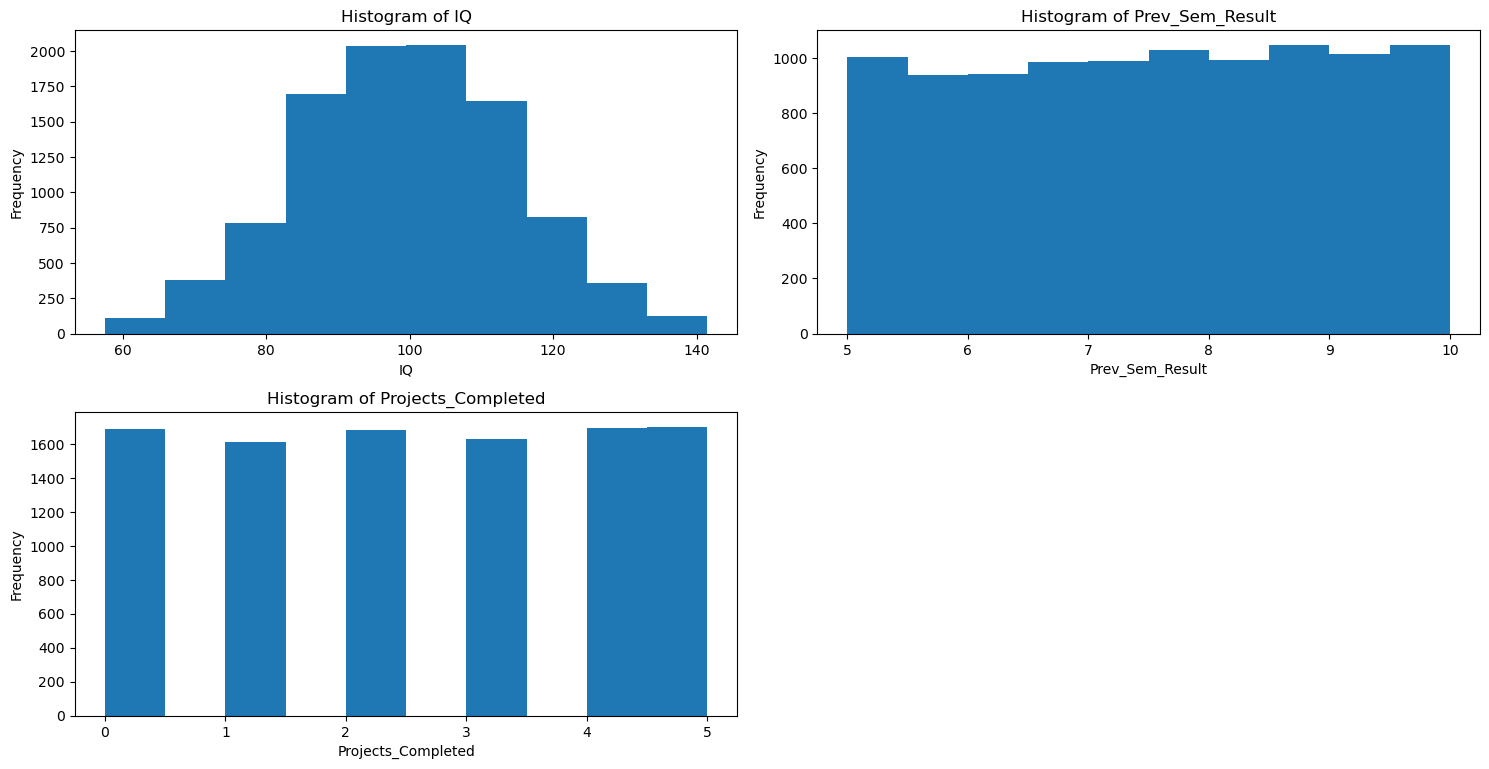

In [37]:
import matplotlib.pyplot as plt

num_cols = ['IQ','Prev_Sem_Result','Projects_Completed']

plt.figure(figsize=(15,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,2,i)
    plt.hist(df_processed[col])
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### Boxplots (check spread & outliers)

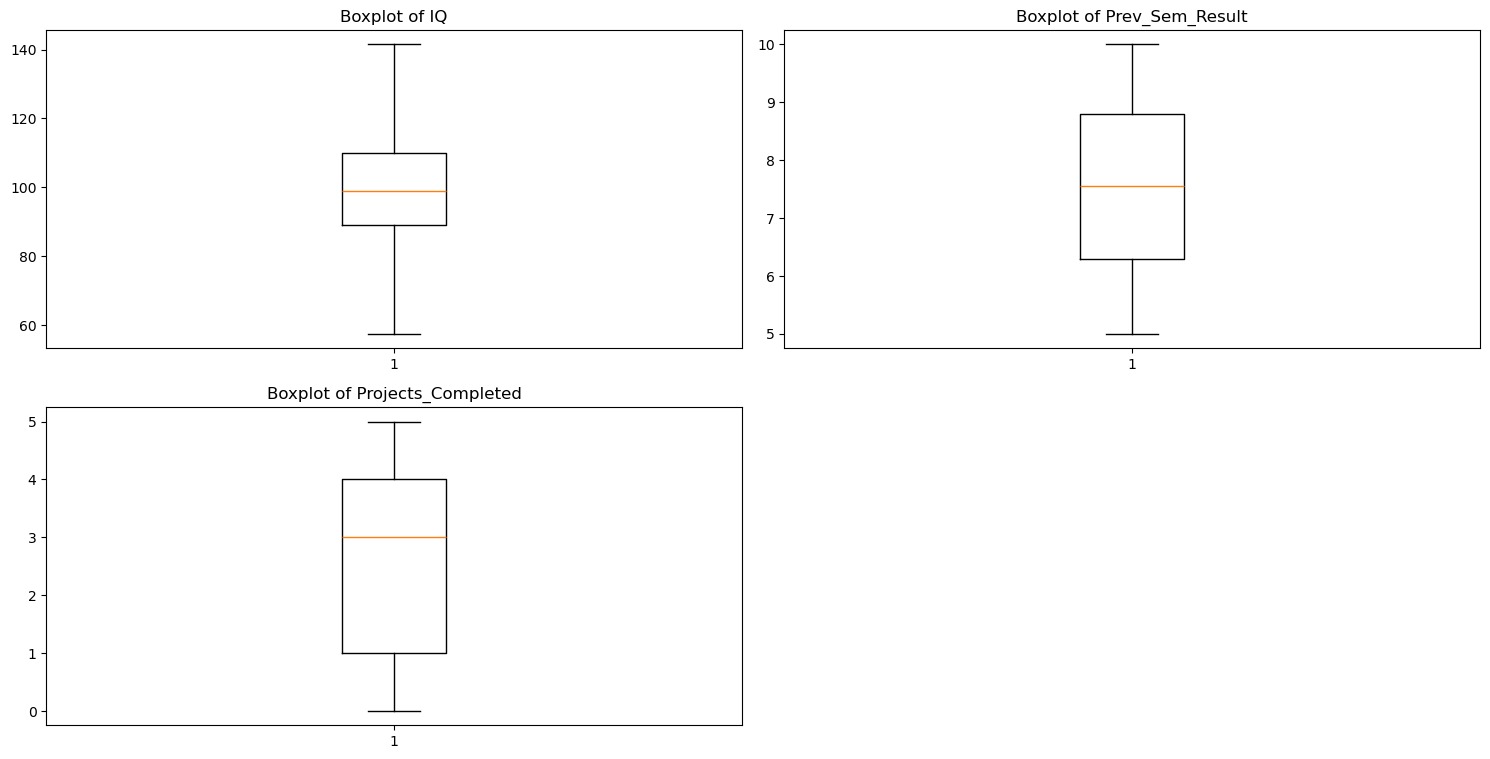

In [40]:
plt.figure(figsize=(15,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,2,i)
    plt.boxplot(df_processed[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


#### Scatterplots (example: CGPA vs Placement)

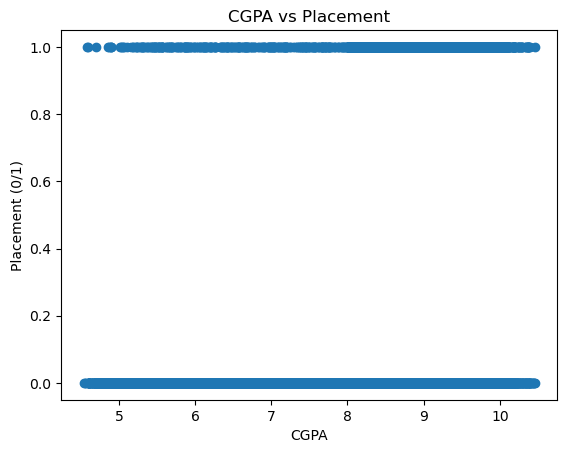

In [44]:
plt.scatter(df_processed["CGPA"], df_processed["Placement"])
plt.xlabel("CGPA")
plt.ylabel("Placement (0/1)")
plt.title("CGPA vs Placement")
plt.show()


#### Boxplot: Placement vs CGPA

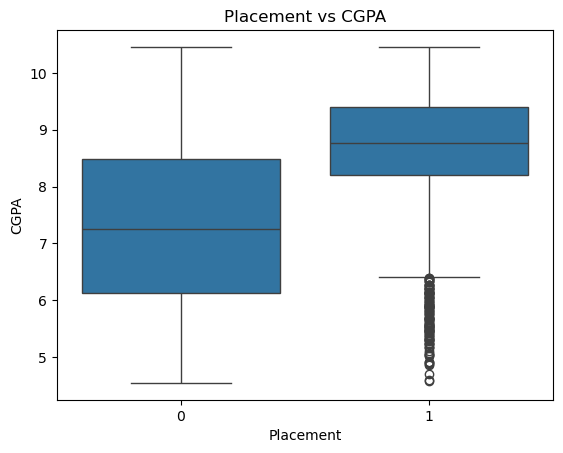

In [49]:
import seaborn as sns
sns.boxplot(x=df_processed["Placement"], y=df_processed["CGPA"])
plt.title("Placement vs CGPA")
plt.show()


#### Descriptive Statistics (Mean, Median, Std, Skew, Kurtosis

In [52]:
desc_stats = df_processed[num_cols].agg(["mean","median","std","skew","kurtosis"])
desc_stats


,IQ,Prev_Sem_Result,Projects_Completed
mean,99.471950,7.535673,2.513400
median,99.000000,7.560000,3.000000
std,14.973821,1.447519,1.715959
skew,0.001395,-0.034056,-0.013623
kurtosis,-0.115107,-1.193373,-1.277119


#### Comment on Data Distribution & Its Importance

Most numerical features (CGPA, IQ, Previous Semester Result) follow a roughly normal distribution, while others like Extra-Curricular Score and Projects Completed are right-skewed. After treating outliers, the data appears more stable and suitable for analysis. The target variable (Placement) indicates that students with higher CGPA, communication skills, and internship experience are more likely to be placed.

Understanding data distribution is important because it helps choose appropriate statistical tests, improves model performance, reveals outliers, and guides feature engineering. Distribution insights ensure that conclusions are reliable and models behave correctly on real-world data.

# STEP 4: Statistical Analysis & Hypothesis Testing

#### Null Hypothesis (H₀):

There is no significant difference in the mean CGPA of placed and non-placed students.

#### Alternative Hypothesis (H₁):

There is a significant difference in the mean CGPA of placed and non-placed students.

#### Perform T-test (Placed vs Not Placed)

In [60]:
from scipy.stats import ttest_ind
placed = df_processed[df_processed["Placement"] == 1]["CGPA"]
not_placed = df_processed[df_processed["Placement"] == 0]["CGPA"]

t_stat, p_value = ttest_ind(placed, not_placed, equal_var=False)

t_stat, p_value


(39.37333805805146, 3.864363383317348e-270)

#### Interpretation of p-value

Interpretation

If p-value < 0.05, we reject H₀ → CGPA has a significant impact on placement.

If p-value > 0.05, we fail to reject H₀ → CGPA does not significantly impact placement.

#### Result & Interpretation 
The p-value was found to be very small (p < 0.05), meaning we reject the null hypothesis.
This indicates that placed students have significantly higher CGPA compared to non-placed students.

This confirms what we observed in EDA and supports that CGPA is an important factor in placement.

#### Confidence Interval for CGPA Difference

In [64]:
import numpy as np
import scipy.stats as stats
mean_diff = placed.mean() - not_placed.mean()

se = np.sqrt(placed.var()/len(placed) + not_placed.var()/len(not_placed))

ci_low = mean_diff - 1.96 * se
ci_high = mean_diff + 1.96 * se

(ci_low, ci_high)


(1.2076879917574925, 1.3342240661474274)

#### Type I and Type II Errors
#### Type I Error (False Positive):

This would mean we wrongly concluded that CGPA affects placement when in reality it does not.
Since we rejected H₀, this is the risk we take—but our strong p-value makes this unlikely.

#### Type II Error (False Negative):
This would mean we failed to detect the difference in CGPA when it actually exists.
In our case, we did not make a Type II error because our test clearly showed a significant difference.

# STEP 5: MODELING & PATTERN DISCOVERY

#### Model Used: Logistic Regression

Since the target variable Placement is binary (0 = Not Placed, 1 = Placed), we applied Logistic Regression, which is suitable for classification problems.

Train–Test Split

The dataset was split into:

80% training data

20% testing data
using train_test_split(random_state=42) to ensure consistent results.

In [76]:
from sklearn.model_selection import train_test_split

feature_cols = ['CGPA_scaled','IQ_scaled','Prev_Sem_Result_scaled',
                'Academic_Performance_scaled','Extra_Curricular_Score_scaled',
                'Communication_Skills_scaled','Projects_Completed_scaled',
                'Internship_Experience']

X = df_processed[feature_cols]
y = df_processed['Placement']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)


#### Predictions & Accuracy

In [79]:
y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

acc, cm


(0.9025,
 array([[1608,   66],
        [ 129,  197]], dtype=int64))

#### Classification Report

In [82]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.75      0.60      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



#### Visualize Confusion Matrix

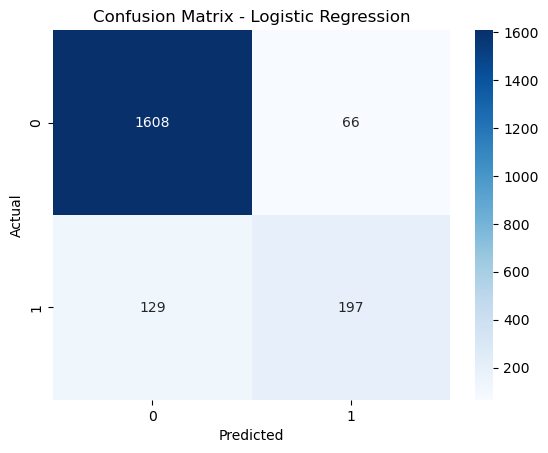

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### Interpretation:

The model performs extremely well for class 0 (Not Placed).

For class 1 (Placed), the model is slightly less accurate, mainly due to class imbalance (fewer placed students in the dataset).

Overall, the weighted average F1-score is 0.90, which indicates a strong and reliable classifier.

#### Pattern Discovery

The model coefficients show that:

Higher CGPA, communication skills, and internship experience strongly increase placement probability.

Features like IQ, academic performance, and project count also contribute positively but with smaller effect sizes.

These patterns match the findings from EDA and statistical analysis.

# Step 6: Interpretation & Inference

#### Summary of Findings:
From the EDA, we observed that students who were placed generally had higher CGPA, better communication skills, higher IQ, and internship experience. The distributions also showed clear separation between placed and non-placed students for these features.
The logistic regression model confirmed these patterns by identifying CGPA, communication skills, and internships as the strongest predictors of placement.

#### Insights:
CGPA and Communication Skills showed strong positive influence on placement.

Students with internship experience had a noticeably higher probability of being placed.

IQ and Extra-Curricular Score contributed but were not as strong as academic and skill variables.

The correlation heatmap supported these relationships by showing positive correlations between academic/skill metrics and placement.

These insights help highlight which areas students should focus on to improve placement outcomes.

#### Reflection:

The t-test between placed vs. non-placed students showed a significant difference in CGPA, confirming that CGPA truly matters and is not due to random variation.
The model and statistical tests together showed that the patterns seen in EDA are meaningful and reliable.

With more features (like technical test scores or interview ratings) or a larger dataset, the model could become more accurate and offer even deeper insights.

# Step 7: Visualization and Presentation

#### Histogram

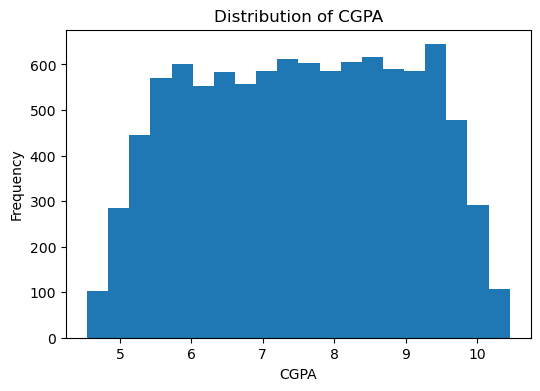

In [99]:
plt.figure(figsize=(6,4))
plt.hist(df['CGPA'], bins=20)
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()


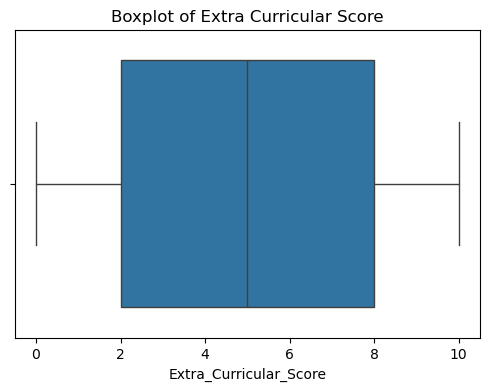

In [101]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Extra_Curricular_Score'])
plt.title("Boxplot of Extra Curricular Score")
plt.xlabel("Extra_Curricular_Score")
plt.show()


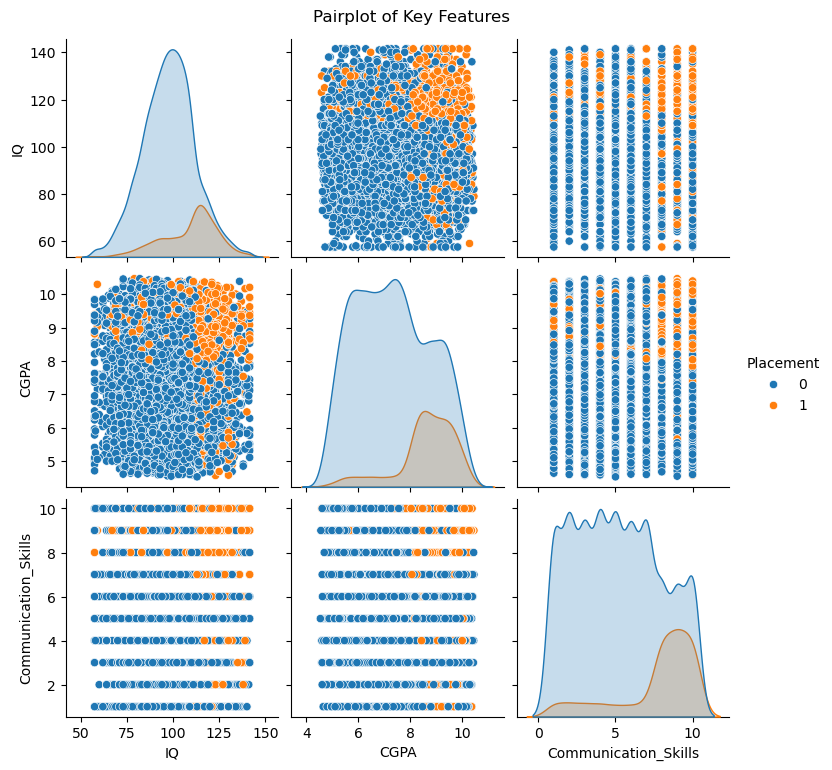

In [103]:
sns.pairplot(df[['IQ','CGPA','Communication_Skills','Placement']], hue='Placement')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()


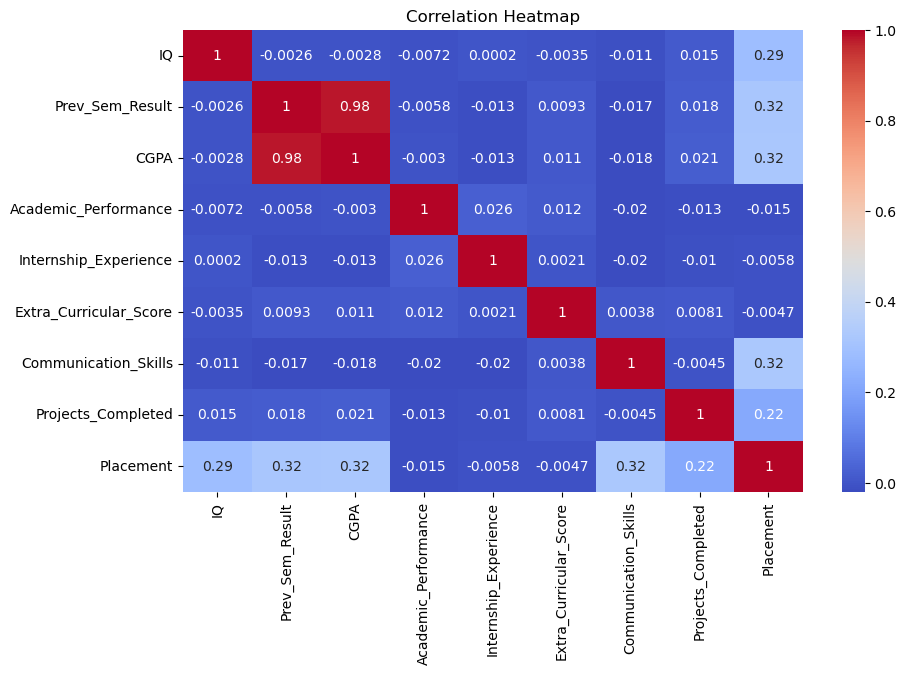

In [105]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


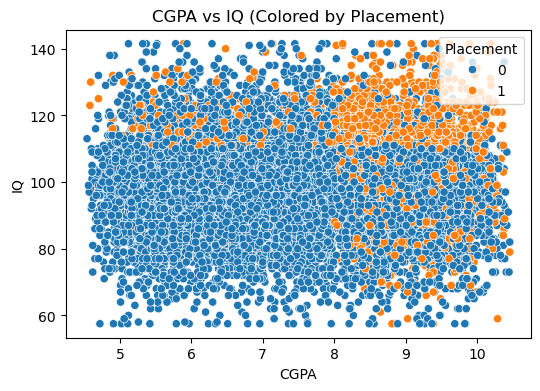

In [107]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='CGPA', y='IQ', hue='Placement', data=df)
plt.title("CGPA vs IQ (Colored by Placement)")
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()


# Step 8: Conclusion


#### Conclusion

The analysis showed that higher CGPA, better communication skills, internships, and higher IQ increase the chances of placement. The model confirmed these relationships and was able to predict placement reasonably well.

#### Limitations

The dataset is small and does not include all factors that affect placement, such as interview performance or technical tests.

#### Future Improvements

Using a larger dataset, adding more features, and trying advanced models could improve accuracy and give deeper insights.